# 1.0 - Data Understanding & Cleaning
**Projeto:** Telco Customer Churn  
**Milestone:** M1/M2  
**Autores:** Salvador Cabeças & Vasco Coelho  
**Data:** Fevereiro 2026  

### Objetivo:
Este notebook documenta o carregamento, a auditoria de tipos e o tratamento inicial dos dados, garantindo que o dataset está tecnicamente apto para a análise estatística avançada.

In [1]:
import pandas as pd
import numpy as np

# Carregar dados
path = '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(path)

# Mostrar as primeiras 5 linhas para inspeção visual inicial
print("--- Visualização Inicial (Head) ---")
display(df.head())

--- Visualização Inicial (Head) ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Estatística descritiva das variáveis numéricas puras
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [3]:
# ==========================================
# 1. TRATAMENTO FINAL E TIPIFICAÇÃO (Fase M1/M2)
# ==========================================

# A. Converter TotalCharges e preencher os 11 nulos (Obrigatório!)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# B. Garantir que o Churn é numérico para correlações
if df['Churn'].dtype == 'O':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype('int64')

# C. Lista dinâmica de colunas para converter (evita erros de nomes)
# Removemos as numéricas e o ID, o que sobra é categórico
cols_para_converter = df.columns.drop(['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'])

for col in cols_para_converter:
    df[col] = df[col].astype('category')

# D. DESCRIBE SEGURO (O ponto onde deu erro)
print("--- Estatística das Categóricas ---")
# Usamos 'category' e 'object' para garantir que ele encontra algo e não dá erro
display(df.describe(include=['category', 'object']).T)

print("\n--- Estatística das Numéricas ---")
display(df.describe().T)

--- Estatística das Categóricas ---


,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
SeniorCitizen,7043,2,0,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088



--- Estatística das Numéricas ---


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80
Churn,7043.0,0.265370,0.441561,0.00,0.00,0.00,1.00,1.00


### Auditoria de Qualidade
Nesta fase, verificamos a existência de valores nulos e a coerência dos tipos de dados atribuídos automaticamente pelo Pandas.

In [4]:
# 1. Informação geral sobre tipos e nulos
print("--- Info Geral ---")
df.info()

# 2. Investigação de valores em branco (Missing Values "escondidos")
# Na Milestone 1 identificámos que 'TotalCharges' contém espaços vazios.
missing_spaces = df[df['TotalCharges'] == " "]
print(f"\nLinhas com espaços em branco em TotalCharges: {len(missing_spaces)}")

# Prova de Negócio: Estes clientes têm tenure=0 (novos contratos)
display(missing_spaces[['customerID', 'tenure', 'TotalCharges']])

--- Info Geral ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   category
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  Paper

,customerID,tenure,TotalCharges


### Data Preparation: Transformação de Variáveis
Para permitir a análise estatística (M2) e a modelação (M3), realizamos as seguintes correções:
1. Converter `TotalCharges` para float (forçando NaN nos espaços vazios).
2. Otimizar variáveis categóricas (tipo `category`) para poupar memória.
3. Codificar a variável alvo `Churn` de forma binária (0 e 1).

In [5]:
# ==========================================================
# 1. DATA PREPARATION & TIPIFICAÇÃO (CRITICAL)
# ==========================================================

# 1. Conversão de TotalCharges e TRATAMENTO DE NULOS
# O errors='coerce' cria NaNs onde havia espaços; o fillna(0) limpa os 11 casos de tenure=0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# 2. Mapeamento da Target (Churn) para Numérico
# Essencial para podermos fazer correlações e modelos de ML
if df['Churn'].dtype == 'O': # Só converte se ainda for String
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype('int64')

# 3. Tipificação Categórica (Otimização de Memória e Algoritmos)
# Definimos as colunas que são qualitativas
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
    'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

print("✅ Transformações concluídas com sucesso!")
print(f"Nulos restantes em TotalCharges: {df['TotalCharges'].isnull().sum()}")
df.info()

✅ Transformações concluídas com sucesso!
Nulos restantes em TotalCharges: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   category
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 

In [6]:
# --- CORREÇÃO DE RIGOR: Tratamento dos 11 nulos ---
# Como tenure=0, o valor faturado acumulado é logicamente 0.0
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Validar se agora temos 7043 em tudo
print(f"Total de nulos após correção: {df['TotalCharges'].isnull().sum()}")

Total de nulos após correção: 0


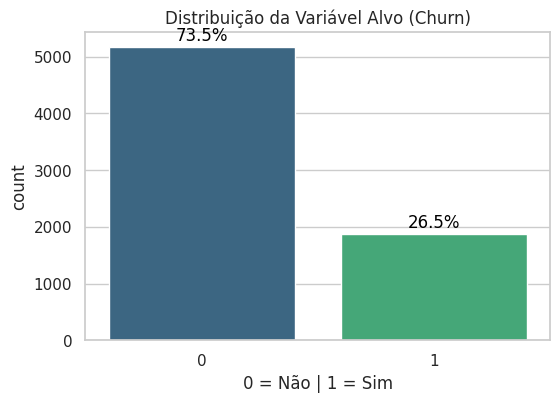

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))

# CORREÇÃO: Adicionamos hue='Churn' e legend=False
ax = sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)

plt.title('Distribuição da Variável Alvo (Churn)')
plt.xlabel('0 = Não | 1 = Sim')

# Adicionar percentagens para análise de equilíbrio
total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

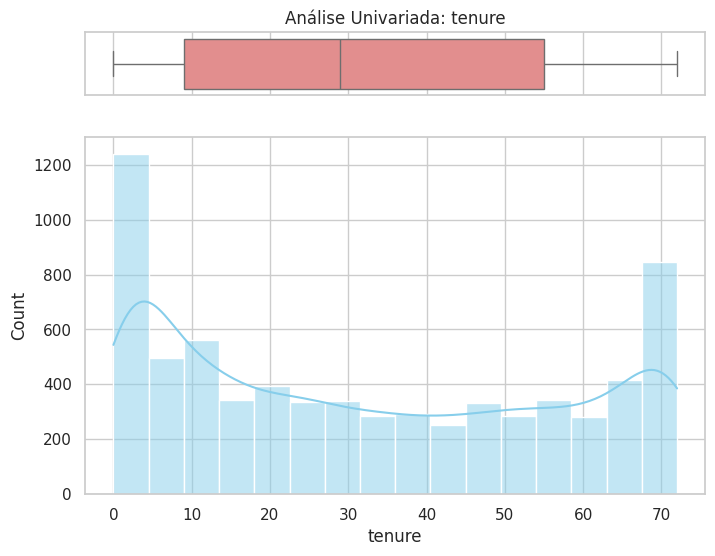

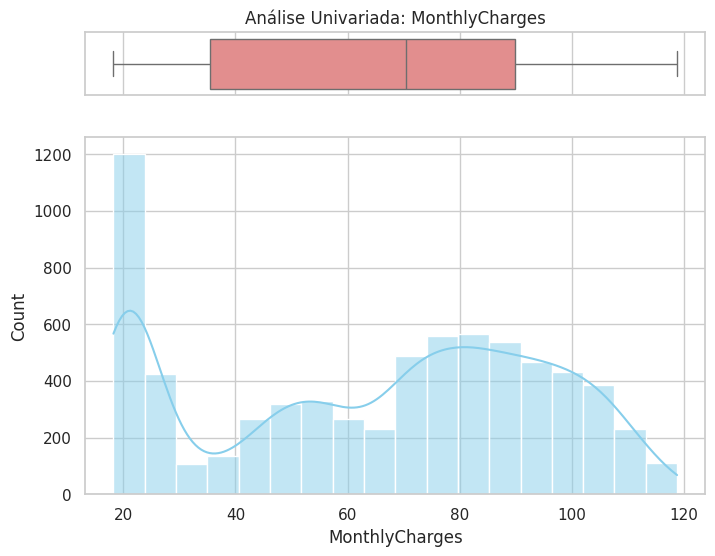

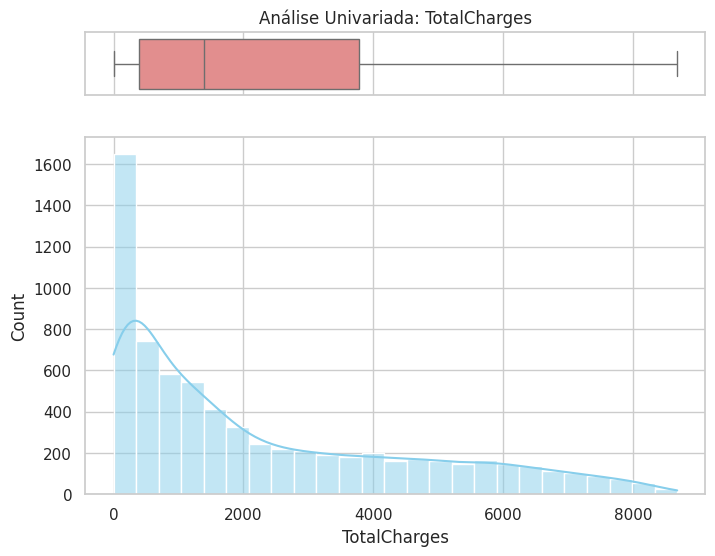

In [8]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_features:
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(8, 6))
    
    sns.boxplot(x=df[col], ax=ax_box, color='lightcoral')
    sns.histplot(df[col], ax=ax_hist, kde=True, color='skyblue')
    
    ax_box.set(title=f'Análise Univariada: {col}')
    ax_box.set(xlabel='')
    plt.show()

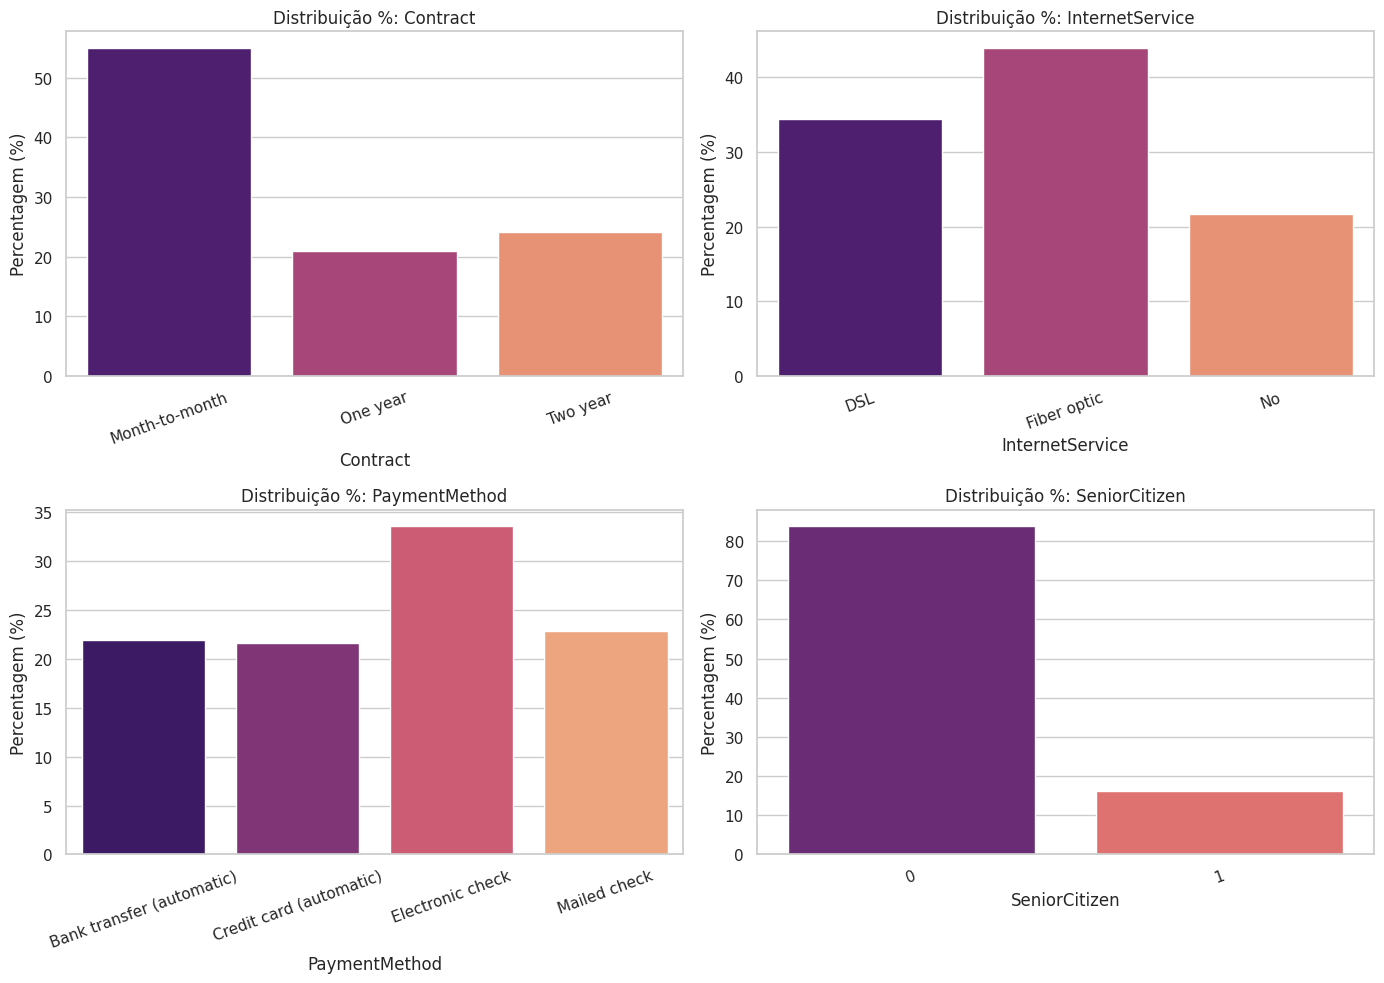

In [9]:
# Analisar as variáveis mais críticas para a diferenciação dos dados
criticas = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']

plt.figure(figsize=(14, 10))
for i, col in enumerate(criticas, 1):
    plt.subplot(2, 2, i)
    
    # Cálculo da frequência relativa (%)
    counts = df[col].value_counts(normalize=True) * 100
    
    # CORREÇÃO: Adicionado hue=counts.index e legend=False
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='magma', legend=False)
    
    plt.title(f'Distribuição %: {col}')
    plt.ylabel('Percentagem (%)')
    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 2.0 - Análise de Correlação


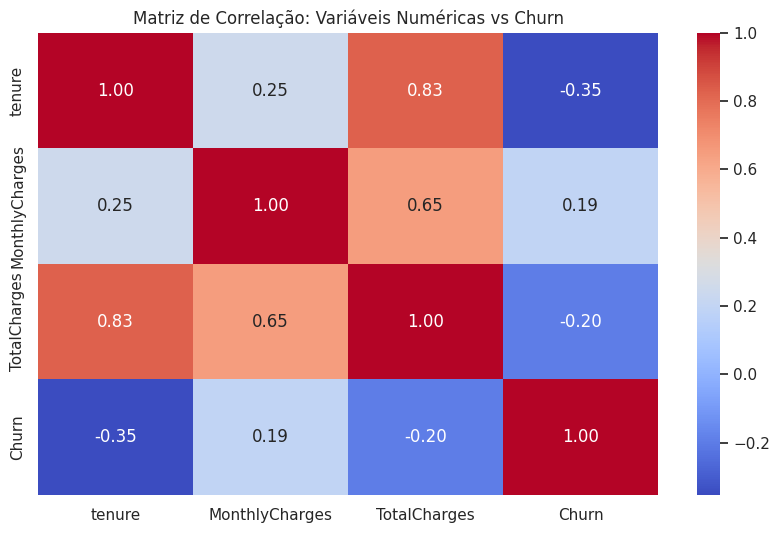

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap de correlação (apenas para numéricas)
plt.figure(figsize=(10, 6))
correlation_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação: Variáveis Numéricas vs Churn')
plt.show()

## 3.0 - Análise Bivariada (Cruzamento com a Target)

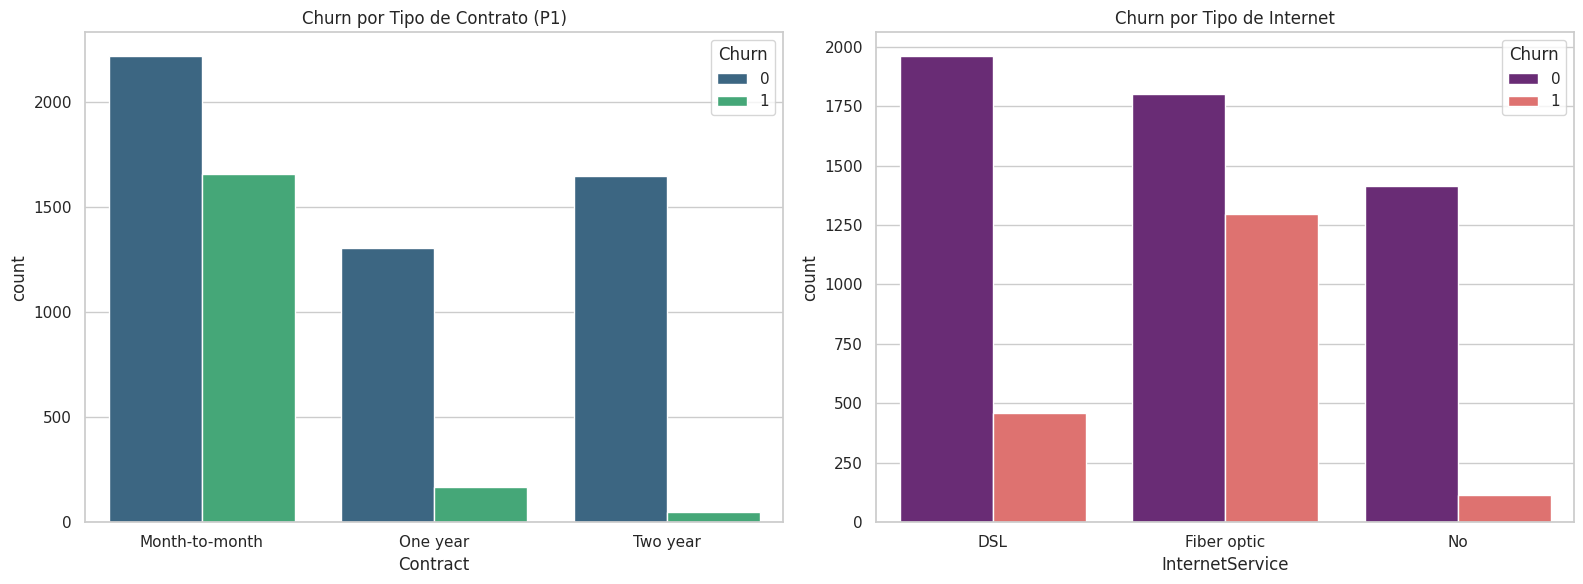

Taxa de Churn por Segmento de Contrato:


Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contrato vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis', ax=axes[0])
axes[0].set_title('Churn por Tipo de Contrato (P1)')

# Internet Service vs Churn
sns.countplot(data=df, x='InternetService', hue='Churn', palette='magma', ax=axes[1])
axes[1].set_title('Churn por Tipo de Internet')

plt.tight_layout()
plt.show()

# Tabela de Percentagem de Churn por Contrato (Diferencial técnico)
print("Taxa de Churn por Segmento de Contrato:")
display(pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100)

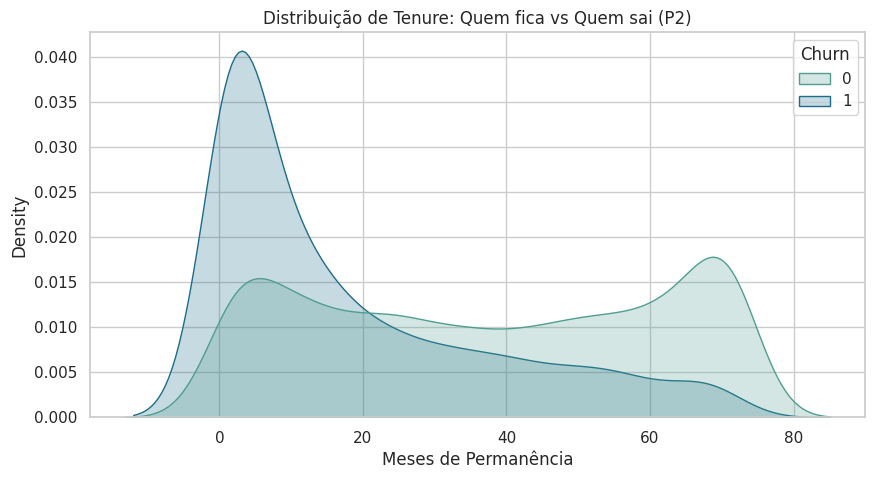

In [12]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='crest')
plt.title('Distribuição de Tenure: Quem fica vs Quem sai (P2)')
plt.xlabel('Meses de Permanência')
plt.show()